# HapSleep — POC final: explicación SHAP + niveles Leve / Moderado / Alto

**Qué junta este notebook:** el puntaje continuo de POC 1.3 + **explicaciones SHAP** (por qué a *esta* persona le sale ese
riesgo) + una **regla fija** que convierte el puntaje en **Leve / Moderado / Alto** (la que el paper de tu compañero pide) +
el **payload** final que recibiría el LLM.

**Datos:** LifeSnaps, las 37 personas con puntaje de sueño de Fitbit (proxy, igual que POC 1.3). Se predice el
`índice de riesgo = 1 − puntaje de sueño de Fitbit` (más alto = peor, como el PSQI).

**Cómo se lee en 4 líneas**
1. El Random Forest estima el índice de riesgo de cada persona **sin haberla visto** (se entrena con las otras 36).
2. SHAP descompone esa estimación: cuánto suma o resta cada variable respecto al promedio del grupo.
3. Una regla fija con dos cortes traduce el índice a Leve / Moderado / Alto. **El nivel lo decide el código, no el LLM.**
4. El LLM recibe el nivel ya decidido + los factores SHAP, y solo redacta.

*Sigue siendo un proxy con n=37: se ensaya el **diseño**, no el desempeño final.*

In [1]:
import sys, json, warnings
from pathlib import Path
try:
    sys.stdout.reconfigure(encoding="utf-8")
except AttributeError:
    pass
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import spearmanr
import shap
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110

DATA_PATH = Path("../POC1/data/daily_fitbit_sema_df_unprocessed.csv")
COL_ID, LABEL_COL, RANDOM_STATE = "id", "sleep_points_percentage", 42
RAW = ["rmssd", "nremhr", "resting_hr", "spo2", "full_sleep_breathing_rate", "minutesToFallAsleep",
       "minutesAsleep", "minutesAwake", "sleep_efficiency", "sleep_points_percentage", "steps", "sedentary_minutes"]
PREDICTOR_VARS = [c for c in RAW if c != LABEL_COL]

# Cortes de nivel, en la escala del PSQI (0-21, más alto = peor). Ver la celda de cortes más abajo.
PSQI_CUT_LEVE = 5      # <= 5  -> Leve     (Buysse 1989: buen dormidor)
PSQI_CUT_ALTO = 10     # > 10  -> Alto     (convención clínica de derivación)
SCALE = 21             # el índice 0-1 del proxy se reescala x21 SOLO para ensayar la regla

# Grupos de variables (para SHAP agrupado: las variables de un grupo están correlacionadas)
GROUPS = {
    "Duración y eficiencia del sueño": ["minutesAsleep_mean", "minutesAwake_mean", "sleep_efficiency_mean", "minutesToFallAsleep_mean"],
    "Regularidad del sueño (variación entre noches)": ["sleep_duration_inconsistency", "minutesAwake_std", "sleep_efficiency_std", "minutesToFallAsleep_std"],
    "Frecuencia cardíaca y HRV": ["resting_hr_mean", "resting_hr_std", "nremhr_mean", "nremhr_std", "rmssd_mean", "rmssd_std"],
    "Respiración y oxígeno": ["full_sleep_breathing_rate_mean", "full_sleep_breathing_rate_std", "spo2_mean", "spo2_std"],
    "Actividad y sedentarismo": ["steps_mean", "steps_std", "sedentary_minutes_mean", "sedentary_minutes_std"],
}


def load_37():
    df = pd.read_csv(DATA_PATH)
    for c in RAW:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    has = df.groupby(COL_ID)[LABEL_COL].apply(lambda s: s.notna().any())
    df = df[df[COL_ID].isin(has[has].index)]
    agg = df.groupby(COL_ID)[RAW].agg(["mean", "std"])
    agg.columns = [f"{c}_{s}" for c, s in agg.columns]
    agg = agg.reset_index().rename(columns={"minutesAsleep_std": "sleep_duration_inconsistency"})
    feats = [c for c in agg.columns if c != COL_ID and not c.startswith(LABEL_COL + "_")]
    agg[feats] = agg[feats].fillna(agg[feats].median())
    return df, agg, feats


raw37, person, feats = load_37()
assert sorted(sum(GROUPS.values(), [])) == sorted(feats), "cada variable debe estar en un grupo"
X = person[feats].reset_index(drop=True)
y = (1 - person[LABEL_COL + "_mean"]).reset_index(drop=True)
ids = person[COL_ID].reset_index(drop=True)
print(f"Personas: {len(X)} | variables: {X.shape[1]} en {len(GROUPS)} grupos")

Personas: 37 | variables: 22 en 5 grupos


## 1. ¿Por qué agrupar? Variables correlacionadas

El paper avisa que SHAP se distorsiona con variables muy correlacionadas (si dos dicen lo mismo, el modelo reparte el
crédito entre ellas casi al azar). Se mide cuántos pares de las 22 variables están muy correlacionadas.

In [2]:
corr = X.corr(method="spearman").abs()
pairs = [(a, b, corr.loc[a, b]) for i, a in enumerate(corr.columns) for b in corr.columns[i + 1:] if corr.loc[a, b] >= 0.7]
pairs.sort(key=lambda t: -t[2])
g_of = {f: g for g, fs in GROUPS.items() for f in fs}
same = sum(g_of[a] == g_of[b] for a, b, _ in pairs)
print(f"Pares de variables con |correlación| >= 0.7: {len(pairs)} de {22*21//2} posibles; {same} caen dentro del mismo grupo")
pd.DataFrame(pairs[:8], columns=["variable A", "variable B", "|Spearman|"]).round(2)

Pares de variables con |correlación| >= 0.7: 4 de 231 posibles; 3 caen dentro del mismo grupo


,variable A,variable B,|Spearman|
0,minutesToFallAsleep_mean,minutesToFallAsleep_std,1.00
1,nremhr_mean,resting_hr_mean,0.82
2,sleep_duration_inconsistency,minutesAwake_std,0.76
3,minutesAsleep_mean,minutesAwake_mean,0.76


## 2. Estimación sin haber visto a la persona + SHAP

Para cada persona: se entrena un Random Forest con las otras 36 (**leave-one-out**), se estima su índice y se calcula su
SHAP con **ese mismo modelo**. Así la estimación y la explicación vienen de un modelo que nunca la vio.

**TreeSHAP** descompone la estimación así: `estimado = promedio del grupo + Σ aporte de cada variable`. Un aporte positivo
empuja el riesgo hacia arriba; uno negativo, hacia abajo. La suma se comprueba abajo (debe cuadrar exacto).

In [3]:
def fit_rf(Xtr, ytr, seed=RANDOM_STATE):
    return RandomForestRegressor(n_estimators=300, max_depth=5, random_state=seed).fit(Xtr, ytr)


n = len(X)
pred = np.zeros(n); shap_vals = np.zeros((n, X.shape[1])); base = np.zeros(n); models = []
for i in range(n):
    tr = X.index != i
    m = fit_rf(X[tr], y[tr]); models.append(m)
    ex = shap.TreeExplainer(m)
    pred[i] = m.predict(X.iloc[[i]])[0]
    shap_vals[i] = ex.shap_values(X.iloc[[i]])[0]
    base[i] = float(np.ravel(ex.expected_value)[0])

err = np.abs(base + shap_vals.sum(axis=1) - pred).max()
print(f"Comprobación aditiva: máx |promedio + Σ SHAP − estimado| = {err:.2e}  (debe ser ~0)")
print(f"Estimación en personas no vistas: Spearman {spearmanr(y, pred).correlation:.2f} | MAE {mean_absolute_error(y, pred):.3f} "
      f"(baseline promedio {np.abs(y - y.mean()).mean():.3f}) | R² {r2_score(y, pred):.2f}")
shap_df = pd.DataFrame(shap_vals, columns=X.columns)
grp_shap = pd.DataFrame({g: shap_df[fs].sum(axis=1) for g, fs in GROUPS.items()})   # SHAP agrupado = suma dentro del grupo

Comprobación aditiva: máx |promedio + Σ SHAP − estimado| = 1.89e-15  (debe ser ~0)
Estimación en personas no vistas: Spearman 0.70 | MAE 0.101 (baseline promedio 0.159) | R² 0.49


## 3. De índice a Leve / Moderado / Alto: cómo se eligieron los cortes

**Qué se hizo y en qué se basa** (los cortes finales los define el equipo; esto es una propuesta con fuente):
- Se buscó si el PSQI trae niveles oficiales. Resultado: el estudio original (Buysse 1989) solo define **dos grupos**:
  buen dormidor (**≤ 5**) y mal dormidor (**> 5**), con sensibilidad 89.6 % y especificidad 86.5 %. **No existe una
  división validada en leve / moderado / severo.** El corte **> 10** aparece en la práctica como umbral de derivación, pero
  es una convención, no un tier validado.
- Por eso se propone: **Leve ≤ 5 · Moderado 6–10 · Alto > 10**. El primer corte tiene validación; el segundo es
  convención. Ambos deben citarse así en la tesis. (Fuentes consultadas: [PSQI en Pitt](https://www.sleep.pitt.edu/psqi),
  [Buysse 1989](https://pubmed.ncbi.nlm.nih.gov/2748771/), [revisión breve del PSQI](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC11973415/).
  Sin verificar contra los PDFs originales.)
- Alternativa descartada: partir la escala 0–21 en tres tercios iguales (0–7 / 8–14 / 15–21). Es simple, pero no
  coincide con el único corte validado (5).
- **Ojo:** el proxy no es PSQI. Para poder ensayar la regla, el índice 0–1 se multiplica por 21 y se le aplican los mismos
  cortes. Es solo un ensayo; con el PSQI real los cortes se aplican directo sobre el puntaje estimado.
- **Ojo 2:** en el proyecto se venía usando "PSQI ≥ 5 = mala calidad"; Buysse define > 5. Hay que unificar el criterio.

Además la regla marca cuando el **rango de incertidumbre** cruza un corte (`levels_in_range`), para que el LLM no hable
con más seguridad de la que hay.

In [4]:
def risk_level(index):
    s = index * SCALE
    return "Leve" if s <= PSQI_CUT_LEVE else ("Moderado" if s <= PSQI_CUT_ALTO else "Alto")


ORD = {"Leve": 0, "Moderado": 1, "Alto": 2}
levels = pd.Series([risk_level(v) for v in pred])
real_levels = pd.Series([risk_level(v) for v in y])
resid = y.values - pred
q05, q95 = np.quantile(resid, [0.05, 0.95])
tab = pd.DataFrame({"estimado por el modelo": levels.value_counts(), "según puntaje real (proxy)": real_levels.value_counts()}) \
        .reindex(["Leve", "Moderado", "Alto"]).fillna(0).astype(int)
tab.loc["Total"] = tab.sum()
print(f"Rango de incertidumbre (errores pasados, 5%–95%): {q05:+.3f} a {q95:+.3f}")
agree = (levels == real_levels).mean()
adj = (np.abs(levels.map(ORD) - real_levels.map(ORD)) <= 1).mean()
print(f"Coincide el nivel exacto en {agree:.0%} de las personas; a lo sumo un nivel de diferencia en {adj:.0%}. "
      f"(Si siempre dijera el nivel más frecuente: {real_levels.value_counts(normalize=True).max():.0%})")
tab

Rango de incertidumbre (errores pasados, 5%–95%): -0.208 a +0.301
Coincide el nivel exacto en 62% de las personas; a lo sumo un nivel de diferencia en 100%. (Si siempre dijera el nivel más frecuente: 49%)


,estimado por el modelo,según puntaje real (proxy)
Leve,1,8
Moderado,24,18
Alto,12,11
Total,37,37


## 4. ¿Qué factores pesan? SHAP agrupado y comparación con la importancia clásica

Se promedia el valor absoluto del SHAP de todas las personas: cuánto mueve cada grupo la estimación en promedio. Se compara
con la importancia clásica (Gini) que se usaba antes.

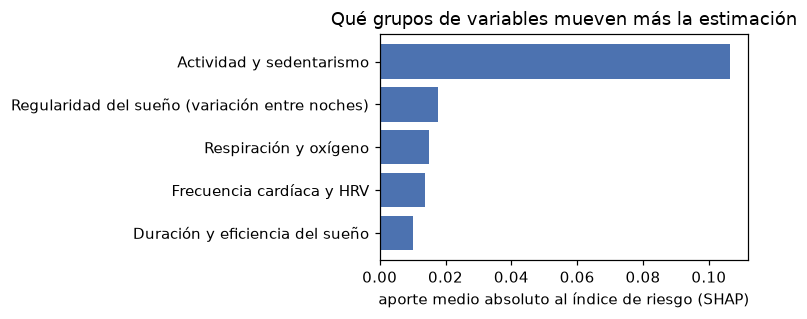

Concordancia de rankings de variables (Spearman) SHAP vs Gini: 0.96
Top 5 SHAP : ['sedentary_minutes_mean', 'full_sleep_breathing_rate_std', 'sleep_duration_inconsistency', 'resting_hr_mean', 'nremhr_std']
Top 5 Gini : ['sedentary_minutes_mean', 'sleep_duration_inconsistency', 'full_sleep_breathing_rate_std', 'resting_hr_mean', 'nremhr_std']


In [5]:
glob = grp_shap.abs().mean().sort_values()
fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(glob.index, glob.values, color="#4C72B0")
ax.set_xlabel("aporte medio absoluto al índice de riesgo (SHAP)")
ax.set_title("Qué grupos de variables mueven más la estimación")
plt.tight_layout(); plt.show()

full = fit_rf(X, y)
gini = pd.Series(full.feature_importances_, index=X.columns)
mean_abs = shap_df.abs().mean()
print(f"Concordancia de rankings de variables (Spearman) SHAP vs Gini: {spearmanr(gini, mean_abs).correlation:.2f}")
print("Top 5 SHAP :", list(mean_abs.sort_values(ascending=False).head(5).index))
print("Top 5 Gini :", list(gini.sort_values(ascending=False).head(5).index))

## 5. ¿Son estables las explicaciones? (lo que el paper llama estabilidad)

Se entrena 20 veces el modelo con 80 % de las personas elegidas al azar y se mira si el grupo que más pesa es siempre el
mismo y si el orden de los grupos se parece entre repeticiones. Si cambiara cada vez, no se podría fiar el LLM de ello.

In [6]:
rng = np.random.default_rng(RANDOM_STATE)
rank_runs, top1 = [], []
for r in range(20):
    idx = rng.choice(n, size=int(0.8 * n), replace=False)
    m = fit_rf(X.iloc[idx], y.iloc[idx], seed=RANDOM_STATE + r)
    sv = pd.DataFrame(shap.TreeExplainer(m).shap_values(X), columns=X.columns)
    g = pd.Series({k: sv[fs].sum(axis=1).abs().mean() for k, fs in GROUPS.items()})
    rank_runs.append(g); top1.append(g.idxmax())
R = pd.DataFrame(rank_runs)
rho = [spearmanr(R.iloc[i], R.iloc[j]).correlation for i in range(20) for j in range(i + 1, 20)]
print("Grupo que más pesa en cada una de las 20 repeticiones:")
print(pd.Series(top1).value_counts().to_string())
print(f"\nAcuerdo del orden de los 5 grupos entre repeticiones (Spearman medio): {np.mean(rho):.2f} (mín {np.min(rho):.2f})")

Grupo que más pesa en cada una de las 20 repeticiones:
Actividad y sedentarismo    20

Acuerdo del orden de los 5 grupos entre repeticiones (Spearman medio): 0.69 (mín 0.00)


## 6. ¿La explicación es fiel al modelo? (prueba de "neutralizar")

Si el grupo que SHAP señala de verdad mueve la estimación, quitarle su efecto (poner sus variables en el valor típico del
grupo) debería **bajar** el riesgo estimado, y más que hacerlo con un grupo cualquiera. Se hace con el modelo de cada
persona. *Mide fidelidad al modelo, no que el factor sea la causa real del mal sueño.*

In [7]:
drop_top, drop_other = [], []
for i in range(n):
    m = models[i]; tr = X.index != i; med = X[tr].median()
    gs = grp_shap.iloc[i]

    def drop(g):
        xi = X.iloc[[i]].copy(); xi[GROUPS[g]] = med[GROUPS[g]].values
        return pred[i] - m.predict(xi)[0]

    top = gs.idxmax()
    if gs[top] <= 0:
        continue
    drop_top.append(drop(top)); drop_other.append(np.mean([drop(g) for g in GROUPS if g != top]))
drop_top, drop_other = np.array(drop_top), np.array(drop_other)
print(f"Personas evaluadas (con algún grupo que sube el riesgo): {len(drop_top)}")
print(f"Baja media del índice al neutralizar el grupo señalado por SHAP: {drop_top.mean():+.3f}")
print(f"Baja media al neutralizar un grupo cualquiera de los otros 4:     {drop_other.mean():+.3f}")
print(f"En {np.mean(drop_top > drop_other):.0%} de las personas el grupo señalado por SHAP baja más el riesgo que el promedio de los otros")

Personas evaluadas (con algún grupo que sube el riesgo): 34
Baja media del índice al neutralizar el grupo señalado por SHAP: +0.096
Baja media al neutralizar un grupo cualquiera de los otros 4:     -0.001
En 94% de las personas el grupo señalado por SHAP baja más el riesgo que el promedio de los otros


## 7. Salida final de ML1 para el LLM

Cada payload lleva el **nivel ya decidido**, el índice con su rango, los grupos que **suben** el riesgo y el que más lo
**baja** (protector), y el valor real de la persona frente al típico del grupo en la variable principal de cada grupo. El
campo `explanation_note` recuerda al LLM que son factores asociados que el modelo usó, no causas.

In [8]:
pop_med = X.median()
nights = raw37.groupby(COL_ID)["minutesAsleep"].count()
missing = {pid: [v for v in PREDICTOR_VARS if g[v].notna().sum() == 0] for pid, g in raw37.groupby(COL_ID)}


def factor(i, g, sign):
    fs = GROUPS[g]
    main = shap_df.loc[i, fs].abs().idxmax()
    return {"group": g, "shap_contribution": round(float(grp_shap.loc[i, g]), 3), "direction": sign,
            "main_variable": main, "person_value": round(float(X.loc[i, main]), 2),
            "group_median": round(float(pop_med[main]), 2)}


def payload(i):
    est = float(pred[i]); lo, hi = float(np.clip(est + q05, 0, 1)), float(np.clip(est + q95, 0, 1))
    gs = grp_shap.iloc[i].sort_values(ascending=False)
    up = [factor(i, g, "sube el riesgo") for g in gs.index if gs[g] > 0.005][:3]
    down = [factor(i, g, "baja el riesgo") for g in gs.index[::-1] if gs[g] < -0.005][:1]
    return {"student_id": ids[i], "risk_level": risk_level(est),
            "estimated_risk_index": round(est, 3), "estimated_range_90": [round(lo, 3), round(hi, 3)],
            "levels_in_range": [k for k in ORD if ORD[risk_level(lo)] <= ORD[k] <= ORD[risk_level(hi)]],
            "risk_factors": up, "protective_factor": down,
            "data_quality": {"nights_with_sleep_data": int(nights[ids[i]]), "missing_variables": missing[ids[i]]},
            "explanation_note": "Factores asociados que el modelo usó; no son causas comprobadas. No es un diagnóstico."}


order = {"Alto": int(np.argmax(pred)), "Moderado": int(np.argmin(np.abs(pred * SCALE - 7.5))), "Leve": int(np.argmin(pred))}
examples = {k: payload(i) for k, i in order.items()}
Path("payload_examples.json").write_text(json.dumps(examples, indent=2, ensure_ascii=False), encoding="utf-8")
for k, p in examples.items():
    print(f"### Ejemplo, nivel estimado {k}"); print(json.dumps(p, indent=2, ensure_ascii=False)); print()

### Ejemplo, nivel estimado Alto
{
  "student_id": "621e342e67b776a2404ce460",
  "risk_level": "Alto",
  "estimated_risk_index": 0.68,
  "estimated_range_90": [
    0.472,
    0.981
  ],
  "levels_in_range": [
    "Moderado",
    "Alto"
  ],
  "risk_factors": [
    {
      "group": "Actividad y sedentarismo",
      "shap_contribution": 0.193,
      "direction": "sube el riesgo",
      "main_variable": "sedentary_minutes_mean",
      "person_value": 1236.71,
      "group_median": 874.7
    },
    {
      "group": "Frecuencia cardíaca y HRV",
      "shap_contribution": 0.04,
      "direction": "sube el riesgo",
      "main_variable": "resting_hr_mean",
      "person_value": 61.73,
      "group_median": 65.57
    },
    {
      "group": "Regularidad del sueño (variación entre noches)",
      "shap_contribution": 0.019,
      "direction": "sube el riesgo",
      "main_variable": "minutesAwake_std",
      "person_value": 28.54,
      "group_median": 19.66
    }
  ],
  "protective_factor": [

## Lectura de los resultados

**Lo que funciona**
- **SHAP cuadra y es fiel al modelo:** la suma de aportes reproduce la estimación (error ~1e-15). Al neutralizar el grupo que
  SHAP señala, el índice baja +0.096 en promedio, contra −0.001 con un grupo cualquiera; en 94 % de las personas el grupo
  señalado baja más el riesgo que el promedio de los otros.
- **El factor principal es estable:** en las 20 repeticiones el grupo que más pesa es siempre *Actividad y sedentarismo*.
- **SHAP y la importancia clásica coinciden** en las variables principales (Spearman 0.96), así que pasar a SHAP no cambia la
  historia; solo aporta la explicación **por persona** (positivo/negativo, con su valor real).
- La regla de niveles es determinista y nunca se equivoca por más de un nivel en este ensayo (100 %).

**Límites que deja a la vista**
- **El modelo se contrae hacia el centro:** casi todos quedan en Moderado (24 de 37) y solo 1 en Leve, cuando según el puntaje
  real (proxy) hay 8. Es lo que ya anticipó el laboratorio sintético (POC 1.5): con señal débil, el puntaje estimado se
  acerca al promedio. El nivel exacto coincide en 62 % (49 % diría siempre el más frecuente): mejora al azar, pero poco.
- **Solo el primer lugar es estable.** Del segundo grupo en adelante, el orden cambia entre repeticiones (acuerdo medio 0.69,
  mínimo 0.00). Al LLM conviene darle **el factor principal con confianza y los demás como secundarios**.
- **El factor dominante (minutos sedentarios) probablemente no estará en todos los relojes:** según la investigación
  multi-wearable, Health Connect no expone minutos sedentarios. Además, con este proxy no se descarta que su peso venga en
  parte de cómo se construye la etiqueta. Hay que revisarlo cuando exista el PSQI.
- Con n=37 y un proxy, **esto ensaya el diseño, no el desempeño**. Los cortes 5 y 10 son de la escala PSQI y aquí se aplican
  a un índice reescalado; con el PSQI real se aplican directo.

**Qué queda para el PoC del LLM:** usar `payload_examples.json` (o generar más con la función `payload`) y comparar las
recomendaciones del LLM **con** y **sin** los factores SHAP.
